# Sine–Gordon Equation using MQ Quasi-Interpolation ($\mathcal{L}_{W_2}$)

This notebook is a detailed implementation of the method described in the uploaded paper. It explains:

1. The Sine–Gordon equation.
2. IMQ radial basis functions.
3. MQ quasi-interpolation.
4. Construction of the $\mathcal{L}_{W_2}$ operator.
5. Numerical time-stepping scheme.
6. Example 1 from the paper.
7. Error computation and visualization.

The notebook is intended as a learning document, so every major step is accompanied by explanations.



## Governing Equation

The one-dimensional Sine–Gordon equation is

$$
u_{tt}=u_{xx}-\sin(u).
$$

with initial conditions

$$
u(x,0)=f(x), \qquad u_t(x,0)=g(x),
$$

and suitable boundary conditions.

The paper approximates the spatial derivative using MQ quasi-interpolation and the time derivative using finite differences.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

np.set_printoptions(suppress=True)



## IMQ Radial Basis Function

The paper uses the inverse multiquadric basis

$$
\phi(r)=\frac{s^2}{(s^2+r^2)^{3/2}}.
$$

where \(s\) is the shape parameter.


In [3]:
def imq_rbf(r, s):
    return s**2 / (s**2 + r**2)**1.5



## MQ Basis Function

The multiquadric basis is

$$
\Phi(r)=\sqrt{c^2+r^2}.
$$

where \(c\) is another shape parameter.


In [4]:
def mq_basis(r, c):
    return np.sqrt(c**2 + r**2)


## Spatial Grid

Create a uniform spatial discretization.


In [5]:
a = -1.0
b = 1.0
h = 0.01

x = np.arange(a, b + h, h)
n = len(x) - 1

print("Number of intervals:", n)


Number of intervals: 200


## Example 1

The paper considers

$$u(x,0)=\sin(\pi x),$$

$$u_t(x,0)=0.$$

Exact solution:

$$u(x,t)=\frac12[\sin(\pi(x+t))+\sin(\pi(x-t))].$$


In [6]:
def exact_solution(x, t):
    return 0.5*(np.sin(np.pi*(x+t)) + np.sin(np.pi*(x-t)))

u0 = np.sin(np.pi*x)
v0 = np.zeros_like(x)


## Selection of Interpolation Centers

The paper uses a reduced set of interpolation centers.


In [7]:
K = 8
center_idx = np.arange(1, len(x)-1, K)

xc = x[center_idx]
N = len(xc)

print("Number of centers =", N)


Number of centers = 25


## Approximation of the Second Derivative Data

Equation (13) in the paper uses a local finite-difference approximation for the second derivative at interpolation centers.


In [8]:
def second_derivative_samples(values, idx):
    d2 = np.zeros(len(idx))

    for m, k in enumerate(idx):
        d2[m] = (values[k+1] - 2*values[k] + values[k-1]) / h**2

    return d2


## IMQ Interpolation Matrix

Construct the interpolation matrix

$$A_{ij}=\phi(|x_i-x_j|).$$


In [9]:
s = 0.8

def build_imq_matrix(centers, s):
    r = np.abs(centers[:, None] - centers[None, :])
    return imq_rbf(r, s)

A = build_imq_matrix(xc, s)
print(A.shape)


(25, 25)


## Recover the Coefficients $\alpha_j$

Solve

$$A\alpha=f''.$$


In [10]:
d2_data = second_derivative_samples(u0, center_idx)

alpha = solve(A, d2_data)

print(alpha[:5])


[  -907.59006103   4454.22808995 -11439.60104132  20599.41937679
 -29378.50641065]


## Approximation of $u_{xx}$

For simplicity, we evaluate the interpolated second derivative directly from the IMQ expansion.


In [11]:
def approximate_uxx(x_eval, centers, alpha, s):
    r = np.abs(x_eval[:, None] - centers[None, :])
    Phi = imq_rbf(r, s)
    return Phi @ alpha



## Time Stepping

The paper uses

$$
u_k^{n+1}
=2u_k^n-u_k^{n-1}
+\tau^2u_{xx}
-\tau^2\sin(u_k^n).
$$


In [12]:
tau = 0.01
T = 1.0

u_prev = u0.copy()

uxx0 = approximate_uxx(x, xc, alpha, s)

u_curr = u_prev + tau*v0 + 0.5*tau**2*(uxx0 - np.sin(u_prev))

times = np.arange(tau, T+tau, tau)

for _ in times[1:]:
    d2_data = second_derivative_samples(u_curr, center_idx)
    alpha = solve(A, d2_data)

    uxx = approximate_uxx(x, xc, alpha, s)

    u_next = (
        2*u_curr
        - u_prev
        + tau**2*uxx
        - tau**2*np.sin(u_curr)
    )

    u_next[0] = 0.0
    u_next[-1] = 0.0

    u_prev = u_curr
    u_curr = u_next


## Error Analysis

Compute RMS and maximum error.


In [13]:
u_exact = exact_solution(x, T)

linf_error = np.max(np.abs(u_curr - u_exact))
rms_error = np.sqrt(np.mean((u_curr - u_exact)**2))

print("L_inf error =", linf_error)
print("RMS error   =", rms_error)


L_inf error = 0.8626638823304934
RMS error   = 0.2213204695182096


## Visualization


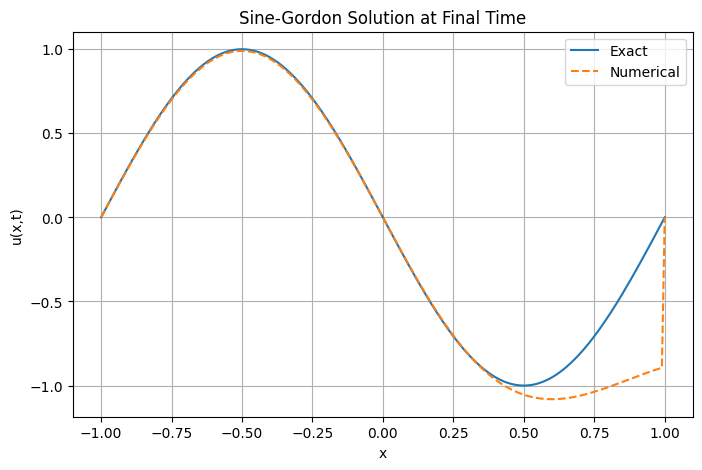

In [14]:
plt.figure(figsize=(8,5))
plt.plot(x, u_exact, label="Exact")
plt.plot(x, u_curr, '--', label="Numerical")
plt.legend()
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Sine-Gordon Solution at Final Time")
plt.grid(True)
plt.show()


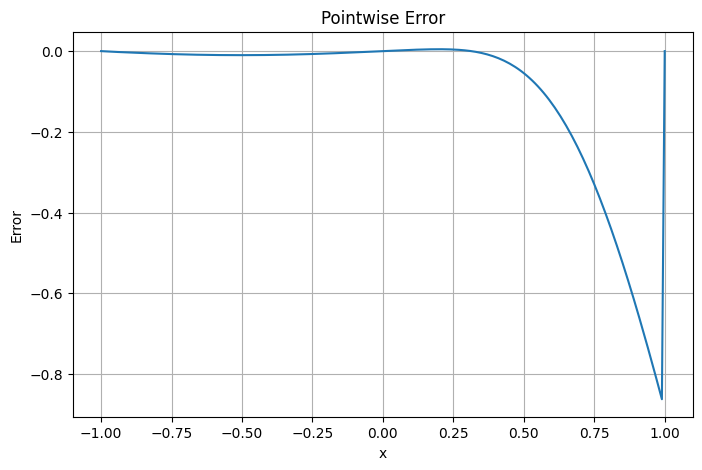

In [15]:
plt.figure(figsize=(8,5))
plt.plot(x, u_curr - u_exact)
plt.xlabel("x")
plt.ylabel("Error")
plt.title("Pointwise Error")
plt.grid(True)
plt.show()


# Further Improvements

This notebook is a pedagogical implementation.

To reproduce the paper exactly, one should:

1. Implement the full $\mathcal{L}_{W_2}$ operator.
2. Compute the $\psi_i(x)$ basis functions from Equation (12).
3. Use the exact center-selection strategy described in the paper.
4. Include both MQ and IMQ correction terms.
5. Reproduce Tables 1 and 2.
6. Perform shape-parameter studies for $c$ and $s$.
